In [3]:
import numpy as np 
import matplotlib.pyplot as plt
import pandas as pd
from ast import literal_eval
from scipy.signal import butter, filtfilt
from matplotlib.ticker import MultipleLocator
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D


In [4]:
key_stimuli = ('ade', 'cad_2.5mm', 'ph4.5', 'qui_2.5mm', 'fex1', 'kw', 'pro_2.5mm')

# key_stimuli = ('qui_2.5mm', 'qui_25um')

## applying filtering and preprocessing steps 
sampling_frequency = 60.85  # Original frequency in Hz
frame_rate = 60.85
window_size_ms = 100  # Window size in milliseconds
window_size_samples = int(sampling_frequency * (window_size_ms / 1000.0))  # Convert to samples
stim_onset = 3180
stimulus_onset_time=53

# --- Stimulus Labels & Colors for plotting ---
stimulus_labels = {
    "ade": "Ade", "cad_2.5mm": "Cad", "fex1": "Fex",
    "kw": "Kin", "ph4.5": "HCl", "pro_2.5mm": "Pro", "qui_2.5mm": "Qun",
    "cad_250um": "Cad Int.", "fex2": "Fex Int.", "pro_250um": "Pro Int.", "qui_250um": "Qun Int.",
    "cad_25um": "Cad Low", "fex3": "Fex Low", "pro_25um": "Pro Low", "qui_25um": "Qun Low"
}

stimulus_colors = {
    "Ade": "plum", "Cad": "mediumorchid", "Fex": "limegreen",
    "Kin": "forestgreen", "HCl": "fuchsia", "Pro": "olive", "Qun": "deeppink", 
    "Cad Int.": "violet", "Fex Int.": "seagreen",
    "Pro Int.": "olivedrab", "Qun Int.": "palevioletred",
    "Cad Low": "plum", "Fex Low": "springgreen",
    "Pro Low": "yellowgreen", "Qun Low": "pink"
    }


stimulus_order = ["Ade", "Cad", "HCl", "Qun", "Fex", "Kin", "Pro"]


In [5]:
def load_behavior_data(path, suffix):
    df = pd.read_csv(path)
    
    # standardize fish_id
    df['fish_id'] = df['fish_id'].astype(str) + suffix
    
    # safely parse stringified lists
    df['angles'] = df['angles'].apply(literal_eval)
    df['bout_indx'] = df['bouts'].apply(literal_eval)
    
    return df

def get_posture_trace(fish_angles, bout_indices_list, extension_frames=10):
    modified_angles = np.array(fish_angles)  # Convert to a NumPy array for easy indexing

    for bout_indices in bout_indices_list:
        # Get the start and end indices of the current bout
        start = bout_indices[0]
        end = bout_indices[-1]

        # Extend the bout by a specified number of frames
        extended_end = min(end + extension_frames, len(fish_angles) - 1)

        # Check if there are points before and after the extended bout for interpolation
        if start > 0 and extended_end < len(fish_angles) - 1:
            # Values before and after the extended bout for interpolation
            pre_bout_value = fish_angles[start - 1]
            post_bout_value = fish_angles[extended_end + 1]
            
            # Generate indices within the bout for interpolation
            bout_range = np.linspace(0, 1, extended_end - start + 1)
            
            # Interpolate linearly across the bout
            interpolated_values = pre_bout_value + bout_range * (post_bout_value - pre_bout_value)
            
            # Replace bout values (including the extended range) in the modified angles with interpolated values
            modified_angles[start:extended_end + 1] = interpolated_values
    
    
    posture = filtfilt(*butter(2, 0.5 / (60.85 / 2), btype='low'), modified_angles)
    
    return posture

def subtract_baseline(posture_trace, baseline_range=slice(1560, 3000)):
    baseline_values = posture_trace[baseline_range]
    baseline_mean = np.mean(baseline_values)
    return posture_trace - baseline_mean

def style_axis(ax):
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.spines["bottom"].set_linewidth(2)
    ax.spines["left"].set_linewidth(2)
    ax.tick_params(axis="both", which="major", width=2, length=5, direction="out")

In [37]:
bhv_fb = load_behavior_data(
    '/Volumes/LaCie/larval_HuC/behavior/7dpf_fb_behavior_traces_posture.csv',
    '_fb'
)

bhv_hb = load_behavior_data(
    '/Volumes/LaCie/larval_HuC/behavior/7dpf_hb_behavior_traces_posture.csv',
    '_hb'
)

bhv = pd.concat([bhv_fb, bhv_hb], ignore_index=True)

# bhv = bhv[bhv['posture_movement']==True]

stimulus_df = bhv[bhv['stimulus'].isin(key_stimuli)]

stimulus_df['posture'] = stimulus_df.apply(lambda x: get_posture_trace(x['angles'], x['bout_indx'], extension_frames=20), axis=1)
stimulus_df['posture'] = stimulus_df['posture'].apply(subtract_baseline)

stimulus_df = stimulus_df.copy()
stimulus_df['fish_id_clean'] = stimulus_df['fish_id'].str.replace(
    r'(_fb|_hb)$', '', regex=True
)

stimulus_df['stimulus'] = stimulus_df['stimulus'].replace(stimulus_labels)

/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_5864/1544916122.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_df['posture'] = stimulus_df.apply(lambda x: get_posture_trace(x['angles'], x['bout_indx'], extension_frames=20), axis=1)
/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_5864/1544916122.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  stimulus_df['posture'] = stimulus_df['posture'].apply(subtract_baseline)


In [5]:
def moving_average(data, window_size=10):
    return np.convolve(data, np.ones(window_size) / window_size, mode="same")


def assign_valence(df, positive_stims):
    df = df.copy()
    df["valence"] = df["stimulus"].apply(lambda x: "POS" if x in positive_stims else "NEG")
    return df


def compute_group_posture_traces(df, group_col="valence", posture_col="posture", use_abs=True):
    """
    Compute mean and SEM posture traces for each group.
    """
    grouped_traces = {}

    for group_name, group in df.groupby(group_col):
        traces = np.stack(group[posture_col].values)

        if use_abs:
            traces = np.abs(traces)

        mean_trace = np.nanmean(traces, axis=0)
        sem_trace = np.nanstd(traces, axis=0) / np.sqrt(np.sum(~np.isnan(traces), axis=0))

        grouped_traces[group_name] = {
            "mean": mean_trace,
            "sem": sem_trace,
            "n": len(group)
        }

    return grouped_traces


def smooth_group_traces(grouped_traces, window_size=100):
    """
    Apply moving average smoothing to mean and SEM traces.
    """
    smoothed = {}

    for group_name, data in grouped_traces.items():
        smoothed[group_name] = {
            "mean": moving_average(data["mean"], window_size),
            "sem": moving_average(data["sem"], window_size),
            "n": data["n"]
        }

    return smoothed


def add_stimulus_shading(ax, start=0, solid_end=10, fade_end=20, alpha_max=0.3, y_top=None):
    """
    Add grey shading from stimulus onset with fade.
    """
    if y_top is None:
        y_top = ax.get_ylim()[1]

    gradient = np.ones((2, 256, 4))
    gradient[:, :, :3] *= 0.5
    gradient[:, :, 3] = np.concatenate([
        np.full(128, alpha_max),
        np.linspace(alpha_max, 0, 128)
    ])

    extent = [start, fade_end, ax.get_ylim()[0], y_top]
    ax.imshow(gradient, extent=extent, origin="lower", aspect="auto", zorder=-1)

    ax.hlines(y=y_top, xmin=start, xmax=solid_end, colors="black", linewidth=4)


def plot_group_posture_traces(
    grouped_traces,
    sampling_freq,
    stimulus_onset_time=53,
    colors=None,
    labels=None,
    window_size=100,
    xlim=(-30, 30),
    ylim=(0, 9)
):
    """
    Plot grouped mean posture traces with SEM.
    """
    if colors is None:
        colors = {"POS": "green", "NEG": "magenta"}

    if labels is None:
        labels = {"POS": "Appetitive", "NEG": "Aversive"}

    smoothed_traces = smooth_group_traces(grouped_traces, window_size=window_size)

    fig, ax = plt.subplots(figsize=(10, 5))

    for group_name, data in smoothed_traces.items():
        mean_deg = np.degrees(data["mean"])
        sem_deg = np.degrees(data["sem"])
        time = np.arange(len(mean_deg)) / sampling_freq - stimulus_onset_time

        ax.plot(
            time,
            mean_deg,
            label=labels.get(group_name, group_name),
            color=colors.get(group_name, "black"),
            linewidth=2.5
        )

        ax.fill_between(
            time,
            mean_deg - sem_deg,
            mean_deg + sem_deg,
            color=colors.get(group_name, "black"),
            alpha=0.15
        )

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    add_stimulus_shading(ax, start=0, solid_end=10, fade_end=20, y_top=ylim[1])

    ax.axvline(0, linestyle="--", color="black", linewidth=2.5)

    ax.set_xlabel("Time Relative to Stimulus Onset (s)", fontsize=28)
    ax.set_ylabel("Posture Trace (°)", fontsize=28)
    ax.legend(fontsize=22, frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=28)
    ax.set_xticks(np.arange(-10, 31, 5))
    ax.xaxis.set_tick_params(which="both", direction="out", length=5, bottom=True, top=False)
    ax.yaxis.set_tick_params(which="both", direction="out", length=5, left=True, right=False)

    plt.tight_layout()
    # plt.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_Neg_Pos_posture_traces.svg", format="svg", dpi=300, bbox_inches="tight")
    plt.show()

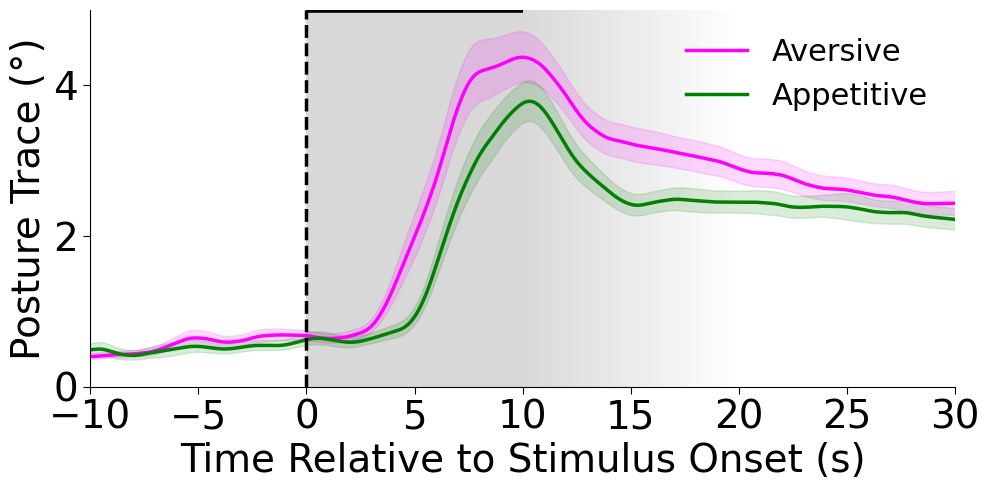

In [8]:
positive_stims = ["Fex", "Kin", "Pro"]

filtered_df_valence = assign_valence(stimulus_df, positive_stims)

grouped_posture_traces = compute_group_posture_traces(
    filtered_df_valence,
    group_col="valence",
    posture_col="posture",
    use_abs=True
)

plot_group_posture_traces(
    grouped_traces=grouped_posture_traces,
    sampling_freq=sampling_frequency,
    stimulus_onset_time=53,
    colors={"POS": "green", "NEG": "magenta"},
    labels={"POS": "Appetitive", "NEG": "Aversive"},
    window_size=100,
    xlim=(-10, 30),
    ylim=(0, 5)
)


In [7]:
def moving_average(data, window_size=100):
    return np.convolve(data, np.ones(window_size) / window_size, mode="same")


def compute_stimulus_posture_traces(df, posture_col="posture", use_abs=True):
    traces_by_stimulus = {}

    for stimulus, group in df.groupby("stimulus"):
        traces = np.stack(group[posture_col].values)

        if use_abs:
            traces = np.abs(traces)

        mean_trace = np.nanmean(traces, axis=0)
        sem_trace = np.nanstd(traces, axis=0) / np.sqrt(np.sum(~np.isnan(traces), axis=0))

        traces_by_stimulus[stimulus] = {
            "mean": mean_trace,
            "sem": sem_trace,
            "n": len(group)
        }

    return traces_by_stimulus


def plot_stimulus_posture_traces(
    traces_by_stimulus,
    sampling_freq,
    stimulus_onset_time=53,
    stimulus_order=None,
    stimulus_label_map=None,
    stimulus_color_map=None,
    window_size=100,
    xlim=(-30, 30),
    ylim=(0, 9)
):
    fig, ax = plt.subplots(figsize=(8, 6))

    if stimulus_order is None:
        stimulus_order = list(traces_by_stimulus.keys())

    for stimulus in stimulus_order:
        if stimulus not in traces_by_stimulus:
            continue

        data = traces_by_stimulus[stimulus]

        smoothed_trace = moving_average(data["mean"], window_size)
        smoothed_sem = moving_average(data["sem"], window_size)

        smoothed_trace_degrees = np.degrees(smoothed_trace)
        smoothed_sem_degrees = np.degrees(smoothed_sem)

        time = np.arange(len(smoothed_trace_degrees)) / sampling_freq - stimulus_onset_time

        label = stimulus_label_map.get(stimulus, stimulus) if stimulus_label_map else stimulus
        color = stimulus_color_map.get(stimulus, None) if stimulus_color_map else None

        ax.plot(time, smoothed_trace_degrees, label=label, color=color, linewidth=2.5)
        ax.fill_between(
            time,
            smoothed_trace_degrees - smoothed_sem_degrees,
            smoothed_trace_degrees + smoothed_sem_degrees,
            color=color,
            alpha=0.1
        )

    # add gradient shading after traces are plotted
    gradient = np.ones((2, 256, 4))
    gradient[:, :, :3] *= 0.5
    gradient[:, :, 3] = np.concatenate([
        np.full(128, 0.3),
        np.linspace(0.3, 0, 128)
    ])

    extent = [0, 20, ylim[0], 10]
    ax.imshow(gradient, extent=extent, origin="lower", aspect="auto", zorder=-1)

    # stimulus bar
    ax.hlines(y=ylim[1], xmin=0, xmax=10, colors="black", linewidth=4)

    ax.set_xlabel("Time Relative to Stimulus Onset (s)", fontsize=28)
    ax.set_ylabel("Posture Trace (°)", fontsize=28)
    ax.legend(fontsize=22, frameon=False)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)
    ax.tick_params(axis="both", labelsize=28)
    ax.xaxis.set_tick_params(which="both", direction="out", length=5, bottom=True, top=False)
    ax.yaxis.set_tick_params(which="both", direction="out", length=5, left=True, right=False)

    ax.set_xlim(xlim)
    ax.set_ylim(ylim)
    ax.xaxis.set_major_locator(MultipleLocator(10))

    plt.tight_layout()
    plt.show()

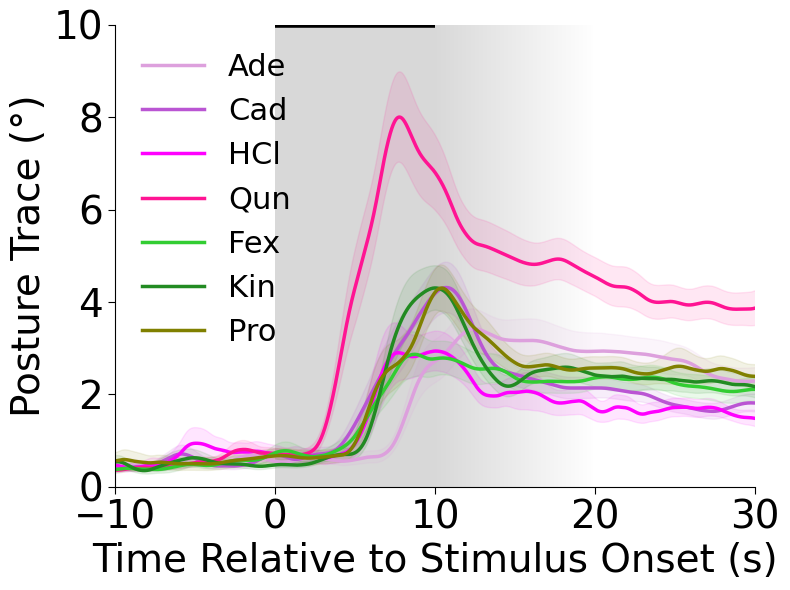

In [7]:
stimulus_traces = compute_stimulus_posture_traces(stimulus_df)

plot_stimulus_posture_traces(
    traces_by_stimulus=stimulus_traces,
    sampling_freq=sampling_frequency,
    stimulus_onset_time=53,
    stimulus_order=stimulus_order,
    stimulus_label_map=stimulus_labels,
    stimulus_color_map=stimulus_colors,
    window_size=100,
    xlim=(-10, 30),
    ylim=(0, 10)
)

## Posture pre/post analysis with a linear mixed-effects model

This section uses:

- **trial-level data** for the model
- **fish-level summaries** for the paired scatter plot
- `fish_base` as the fish random effect
- `session` as an additional random effect only when more than one session is present for a stimulus

The posture trace plotting above is unchanged.

In [8]:
from scipy.stats import circmean
import statsmodels.formula.api as smf
from matplotlib.lines import Line2D


def split_fish_id_and_session(full_fish_id):
    """Split IDs like '230910_fb' into fish_base='230910' and session='fb'."""
    fish_base, session = str(full_fish_id).rsplit("_", 1)
    return fish_base, session


def p_to_symbol(p_value):
    if pd.isna(p_value):
        return "NA"
    if p_value < 0.0001:
        return "****"
    if p_value < 0.001:
        return "***"
    if p_value < 0.01:
        return "**"
    if p_value < 0.05:
        return "*"
    return "ns"


def add_stimulus_display_columns(df, stimulus_labels):
    df = df.copy()
    df["stimulus_label"] = df["stimulus"].map(lambda x: stimulus_labels.get(x, x))
    return df


def compute_trial_and_lmm_posture_tables(
    df,
    posture_col="posture",
    stimulus_col="stimulus",
    fish_id_col="fish_id",
    frame_rate=60.85,
    stimulus_onset_s=53,
    pre_window_s=20,
    post_window_s=20,
    use_abs=True,
    low=0,
    high=np.pi,
):
    """
    Returns:
        trial_summary_df: one row per valid trial with pre/post posture means
        lmm_df: long-format dataframe for mixed models

    Notes:
    - trial_id is assigned within each fish_base x stimulus combination,
      so trials from fb and hb are both retained under the same fish.
    - invalid trials are skipped if a pre/post window is empty or all-NaN.
    - fish_id_clean is set to fish_base to match the mixed-model script style.
    """
    df = df.copy()

    stimulus_frame = int(stimulus_onset_s * frame_rate)
    pre_frames = int(pre_window_s * frame_rate)
    post_frames = int(post_window_s * frame_rate)

    rows = []

    for _, row in df.iterrows():
        trace = np.asarray(row[posture_col], dtype=float)

        if use_abs:
            trace = np.abs(trace)

        pre_start = max(0, stimulus_frame - pre_frames)
        pre_end = stimulus_frame
        post_start = stimulus_frame
        post_end = min(len(trace), stimulus_frame + post_frames)

        pre_trace = trace[pre_start:pre_end]
        post_trace = trace[post_start:post_end]

        if len(pre_trace) == 0 or len(post_trace) == 0:
            continue
        if np.all(np.isnan(pre_trace)) or np.all(np.isnan(post_trace)):
            continue

        pre_mean = np.degrees(circmean(pre_trace, high=high, low=low, nan_policy="omit"))
        post_mean = np.degrees(circmean(post_trace, high=high, low=low, nan_policy="omit"))

        if np.isnan(pre_mean) or np.isnan(post_mean):
            continue

        fish_base, session = split_fish_id_and_session(row[fish_id_col])

        rows.append({
            "fish_id_full": row[fish_id_col],
            "fish_base": str(fish_base),
            "fish_id_clean": str(fish_base),
            "session": str(session),
            "stimulus": row[stimulus_col],
            "pre_amplitude_deg": pre_mean,
            "post_amplitude_deg": post_mean,
        })

    trial_summary_df = pd.DataFrame(rows)

    trial_summary_df["trial_id"] = (
        trial_summary_df
        .groupby(["fish_base", "stimulus"])
        .cumcount() + 1
    )

    lmm_df = trial_summary_df.melt(
        id_vars=["fish_id_full", "fish_base", "fish_id_clean", "session", "stimulus", "trial_id"],
        value_vars=["pre_amplitude_deg", "post_amplitude_deg"],
        var_name="period",
        value_name="amplitude_deg"
    )

    lmm_df["period"] = lmm_df["period"].map({
        "pre_amplitude_deg": "Prestim",
        "post_amplitude_deg": "Poststim"
    })
    lmm_df["condition"] = lmm_df["period"]

    return trial_summary_df, lmm_df


def run_posture_mixed_models(df, group_col):
    """
    Mirrors the bout-frequency script:
    - formula uses categorical condition
    - groups on fish_id_clean
    - adds session random effect only if more than one non-null session exists
    """
    results = []
    fitted_models = {}

    for group_name in sorted(df[group_col].dropna().unique()):
        g = df[df[group_col] == group_name].copy()

        if g.empty:
            continue

        use_session = "session" in g.columns and g["session"].notna().any() and g["session"].nunique() > 1

        try:
            if use_session:
                model = smf.mixedlm(
                    "amplitude_deg ~ condition",
                    g,
                    groups=g["fish_id_clean"],
                    vc_formula={"session": "0 + C(session)"}
                )
            else:
                model = smf.mixedlm(
                    "amplitude_deg ~ condition",
                    g,
                    groups=g["fish_id_clean"]
                )

            fit = model.fit()
            fitted_models[group_name] = fit

            pvals = fit.pvalues
            if "condition[T.Poststim]" in pvals:
                p_value = pvals["condition[T.Poststim]"]
                effect_name = "condition[T.Poststim]"
            elif "condition[T.Prestim]" in pvals:
                p_value = pvals["condition[T.Prestim]"]
                effect_name = "condition[T.Prestim]"
            else:
                p_value = np.nan
                effect_name = None

            ci = fit.conf_int()
            ci_low = ci.loc[effect_name, 0] if effect_name in ci.index else np.nan
            ci_high = ci.loc[effect_name, 1] if effect_name in ci.index else np.nan
            estimate = fit.params.get(effect_name, np.nan)

            results.append({
                group_col: group_name,
                "n_fish": g["fish_id_clean"].nunique(),
                "n_sessions": g["session"].nunique(),
                "n_trials": g["trial_id"].nunique(),
                "estimate_post_vs_pre": estimate,
                "ci_low": ci_low,
                "ci_high": ci_high,
                "p_value": p_value,
                "significance": p_to_symbol(p_value),
            })
        except Exception as exc:
            results.append({
                group_col: group_name,
                "n_fish": g["fish_id_clean"].nunique(),
                "n_sessions": g["session"].nunique(),
                "n_trials": g["trial_id"].nunique(),
                "estimate_post_vs_pre": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "p_value": np.nan,
                "significance": "NA",
                "model_error": str(exc),
            })

    return pd.DataFrame(results), fitted_models


def make_fish_plot_summary(lmm_df):
    """
    Fish-level summary for plotting:
    average all valid trials across available sessions,
    so each fish contributes one Prestim and one Poststim value per stimulus.
    """
    fish_summary_df = (
        lmm_df
        .groupby(
            ["fish_id_clean", "stimulus", "stimulus_label", "condition"],
            observed=False
        )["amplitude_deg"]
        .mean()
        .reset_index()
    )

    return fish_summary_df


def make_per_fish_summary_table(lmm_df):
    """
    Per-fish summary table like the user's example:
    one row per fish x stimulus x condition, with mean/std/count.
    """
    per_fish_summary_df = (
        lmm_df
        .groupby(
            ["fish_id_clean", "stimulus_label", "condition"],
            observed=False
        )
        .agg(
            fish_mean=("amplitude_deg", "mean"),
            fish_std=("amplitude_deg", "std"),
            n_observations=("trial_id", "nunique"),
        )
        .reset_index()
        .rename(columns={
            "stimulus_label": "stimulus",
        })
    )

    return per_fish_summary_df


def plot_paired_fish_by_stimulus(
    fish_plot_df,
    results_df,
    group_col,
    group_order,
    group_title_map,
    group_color_map,
    ylabel="Posture Angle (°)",
    figsize=(12, 5),
):
    fig, axes = plt.subplots(1, len(group_order), figsize=figsize, sharey=True)

    if len(group_order) == 1:
        axes = [axes]

    for i, group_name in enumerate(group_order):
        ax = axes[i]

        g = fish_plot_df[fish_plot_df[group_col] == group_name].copy()

        paired = g.pivot_table(
            index="fish_id_clean",
            columns="condition",
            values="amplitude_deg",
            aggfunc="mean"
        ).dropna()

        if paired.empty:
            ax.set_title(group_title_map.get(group_name, group_name), fontsize=18)
            continue

        for _, row in paired.iterrows():
            ax.plot(
                [0, 1],
                [row["Prestim"], row["Poststim"]],
                color="0.7",
                linewidth=1.2,
                alpha=0.8,
                zorder=1
            )

        ax.scatter(
            np.zeros(len(paired)),
            paired["Prestim"],
            color="black",
            s=35,
            zorder=2
        )
        ax.scatter(
            np.ones(len(paired)),
            paired["Poststim"],
            color=group_color_map.get(group_name, "gray"),
            s=35,
            zorder=2
        )

        pre_mean = paired["Prestim"].mean()
        post_mean = paired["Poststim"].mean()

        ax.hlines(pre_mean, -0.12, 0.12, color="black", linewidth=2.5, zorder=3)
        ax.hlines(post_mean, 0.88, 1.12, color="black", linewidth=2.5, zorder=3)

        p_row = results_df[results_df[group_col] == group_name]
        if not p_row.empty:
            p = p_row.iloc[0]["p_value"]
            ax.text(
                0.5,
                0.98,
                p_to_symbol(p),
                transform=ax.transAxes,
                ha="center",
                va="top",
                fontsize=12,
                fontweight="bold"
            )

        ax.set_xticks([0, 1])
        ax.set_xticklabels(["Pre", "Post"], fontsize=12)
        ax.set_title(group_title_map.get(group_name, group_name), fontsize=18)

        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        ax.tick_params(axis="both", width=1.5, length=4, direction="out", labelsize=14)

    axes[0].set_ylabel(ylabel, fontsize=16)
    plt.tight_layout()
    return fig, axes


def extract_lmm_effects_with_ci(fitted_models, group_title_map):
    rows = []
    for stim, fit in fitted_models.items():
        pvals = fit.pvalues
        if "condition[T.Poststim]" in pvals:
            effect_name = "condition[T.Poststim]"
        elif "condition[T.Prestim]" in pvals:
            effect_name = "condition[T.Prestim]"
        else:
            effect_name = None

        ci = fit.conf_int()
        rows.append({
            "stimulus": stim,
            "stimulus_label": group_title_map.get(stim, stim),
            "estimate": fit.params.get(effect_name, np.nan) if effect_name else np.nan,
            "ci_low": ci.loc[effect_name, 0] if effect_name in ci.index else np.nan,
            "ci_high": ci.loc[effect_name, 1] if effect_name in ci.index else np.nan,
            "p_value": fit.pvalues.get(effect_name, np.nan) if effect_name else np.nan,
        })

    return pd.DataFrame(rows)


def plot_lmm_mean_shift_ci(
    effects_df,
    stimulus_order,
    stimulus_colors,
    ylabel="LMM mean shift (Post - Pre, °)",
    figsize=(9, 5)
):
    plot_df = effects_df.copy()
    plot_df["stimulus_label"] = pd.Categorical(
        plot_df["stimulus_label"],
        categories=stimulus_order,
        ordered=True
    )
    plot_df = plot_df.sort_values("stimulus_label")

    fig, ax = plt.subplots(figsize=figsize)

    max_abs = np.nanmax(np.abs(plot_df[["ci_low", "ci_high"]].to_numpy())) if not plot_df.empty else 1
    if not np.isfinite(max_abs) or max_abs == 0:
        max_abs = 1

    for i, stim_label in enumerate(stimulus_order):
        row = plot_df[plot_df["stimulus_label"] == stim_label]
        if row.empty:
            continue

        est = row["estimate"].iloc[0]
        ci_low = row["ci_low"].iloc[0]
        ci_high = row["ci_high"].iloc[0]
        p = row["p_value"].iloc[0]
        color = stimulus_colors.get(stim_label, "gray")

        if not (pd.isna(est) or pd.isna(ci_low) or pd.isna(ci_high)):
            ax.vlines(i, ci_low, ci_high, linewidth=2)
            ax.scatter(i, est, s=80, color=color, edgecolors="black", linewidths=0.4, zorder=3)
            ax.text(i, ci_high + 0.05 * max_abs, p_to_symbol(p), ha="center", va="bottom",
                    fontsize=14, fontweight="bold")

    ax.axhline(0, color="0.5", linestyle="--", linewidth=1)
    ax.set_xticks(np.arange(len(stimulus_order)))
    ax.set_xticklabels(stimulus_order, rotation=45, ha="right", fontsize=12)
    ax.set_ylabel(ylabel, fontsize=15)

    for spine in ["top", "right"]:
        ax.spines[spine].set_visible(False)

    ax.tick_params(axis="y", labelsize=12)
    ax.tick_params(axis="x", length=0)
    plt.tight_layout()
    plt.show()


In [9]:
trial_summary_df, lmm_df = compute_trial_and_lmm_posture_tables(
    stimulus_df,
    posture_col="posture",
    stimulus_col="stimulus",
    fish_id_col="fish_id",
    frame_rate=frame_rate,
    stimulus_onset_s=stimulus_onset_time,
    pre_window_s=20,
    post_window_s=20,
    use_abs=True,
    low=0,
    high=np.pi
)

trial_summary_df = add_stimulus_display_columns(trial_summary_df, stimulus_labels)
lmm_df = add_stimulus_display_columns(lmm_df, stimulus_labels)

lmm_results_df, fitted_lmm_models = run_posture_mixed_models(lmm_df, group_col="stimulus")
lmm_results_df["stimulus_label"] = lmm_results_df["stimulus"].replace(stimulus_labels)
lmm_results_df["stimulus_label"] = pd.Categorical(
    lmm_results_df["stimulus_label"],
    categories=stimulus_order,
    ordered=True
)
lmm_results_df = lmm_results_df.sort_values("stimulus_label").reset_index(drop=True)



/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with lbfgs
  warnings.warn(
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/base/model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsmodels/regression/mixed_linear_model.py:2200: ConvergenceWarning: Retrying MixedLM optimization with cg
  warnings.warn(
/Users/bethanjenkins/opt/anaconda3/envs/sense/lib/python3.10/site-packages/statsm

In [10]:
fish_plot_df_stimulus = make_fish_plot_summary(lmm_df)
fish_plot_df_stimulus["stimulus"] = pd.Categorical(
    fish_plot_df_stimulus["stimulus"],
    categories=key_stimuli,
    ordered=True
)

per_fish_summary_df = make_per_fish_summary_table(lmm_df)
per_fish_summary_df["stimulus"] = pd.Categorical(
    per_fish_summary_df["stimulus"],
    categories=stimulus_order,
    ordered=True
)
per_fish_summary_df["condition"] = pd.Categorical(
    per_fish_summary_df["condition"],
    categories=["Poststim", "Prestim"],
    ordered=True
)
per_fish_summary_df = per_fish_summary_df.sort_values(
    ["fish_id_clean", "stimulus", "condition"]
).reset_index(drop=True)

effects_df = extract_lmm_effects_with_ci(fitted_lmm_models, stimulus_labels)
effects_df["stimulus_label"] = pd.Categorical(
    effects_df["stimulus_label"],
    categories=stimulus_order,
    ordered=True
)
effects_df = effects_df.sort_values("stimulus_label").reset_index(drop=True)

print("trial_summary_df shape:", trial_summary_df.shape)
print("lmm_df shape:", lmm_df.shape)
print("n fish per stimulus:")
display(fish_plot_df_stimulus.groupby("stimulus", observed=False)["fish_id_clean"].nunique().sort_index())

display(
    lmm_results_df[
        ["stimulus_label", "estimate_post_vs_pre", "ci_low", "ci_high", "p_value", "significance", "n_fish", "n_sessions", "n_trials"]
    ]
)

display(per_fish_summary_df.head(20))

trial_summary_df shape: (328, 9)
lmm_df shape: (656, 10)
n fish per stimulus:


stimulus
ade          0
cad_2.5mm    0
ph4.5        0
qui_2.5mm    0
fex1         0
kw           0
pro_2.5mm    0
Name: fish_id_clean, dtype: int64

,stimulus_label,estimate_post_vs_pre,ci_low,ci_high,p_value,significance,n_fish,n_sessions,n_trials
0,Ade,-1.604811,-2.025681,-1.183941,7.808967e-14,****,10,2,5
1,Cad,-1.824613,-2.250735,-1.398491,4.764110e-17,****,10,2,6
2,HCl,-1.302931,-1.711633,-0.894229,4.149000e-10,****,10,2,6
3,Qun,-4.187382,-4.840062,-3.534702,2.916768e-36,****,10,2,6
4,Fex,-1.576418,-1.880749,-1.272086,3.230290e-24,****,10,2,6
5,Kin,-1.828030,-2.158737,-1.497324,2.375647e-27,****,10,2,6
6,Pro,-1.806451,-2.226984,-1.385918,3.788615e-17,****,10,2,6


,fish_id_clean,stimulus,condition,fish_mean,fish_std,n_observations
0,230713,Ade,Poststim,1.345234,0.663295,2
1,230713,Ade,Prestim,0.197786,0.117320,2
2,230713,Cad,Poststim,2.587207,1.720959,5
3,230713,Cad,Prestim,0.640644,0.822180,5
4,230713,HCl,Poststim,1.648062,0.385967,4
5,230713,HCl,Prestim,0.185491,0.061434,4
6,230713,Qun,Poststim,6.711531,1.829031,6
7,230713,Qun,Prestim,0.247843,0.097019,6
8,230713,Fex,Poststim,2.468511,0.650081,5
9,230713,Fex,Prestim,0.315103,0.194881,5


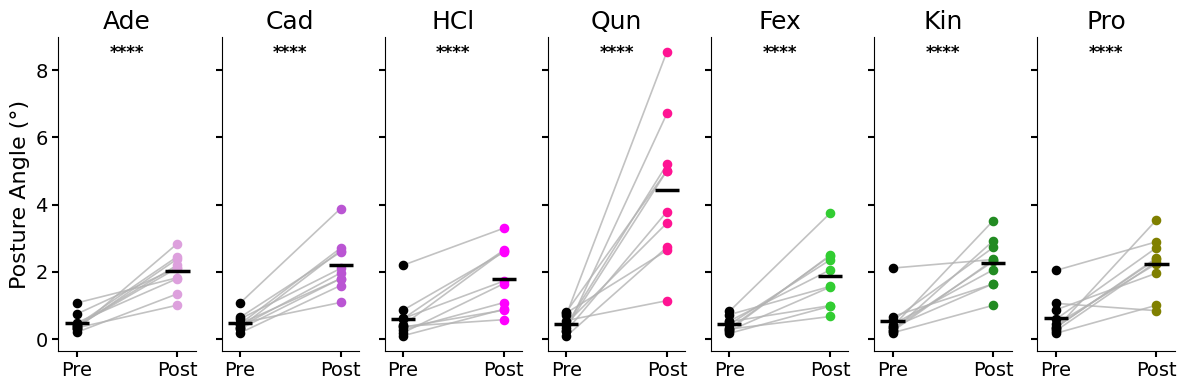

,stimulus,stimulus_label,estimate,ci_low,ci_high,p_value
0,Ade,Ade,-1.604811,-2.025681,-1.183941,7.808967e-14
1,Cad,Cad,-1.824613,-2.250735,-1.398491,4.764110e-17
2,HCl,HCl,-1.302931,-1.711633,-0.894229,4.149000e-10
3,Qun,Qun,-4.187382,-4.840062,-3.534702,2.916768e-36
4,Fex,Fex,-1.576418,-1.880749,-1.272086,3.230290e-24
5,Kin,Kin,-1.828030,-2.158737,-1.497324,2.375647e-27
6,Pro,Pro,-1.806451,-2.226984,-1.385918,3.788615e-17


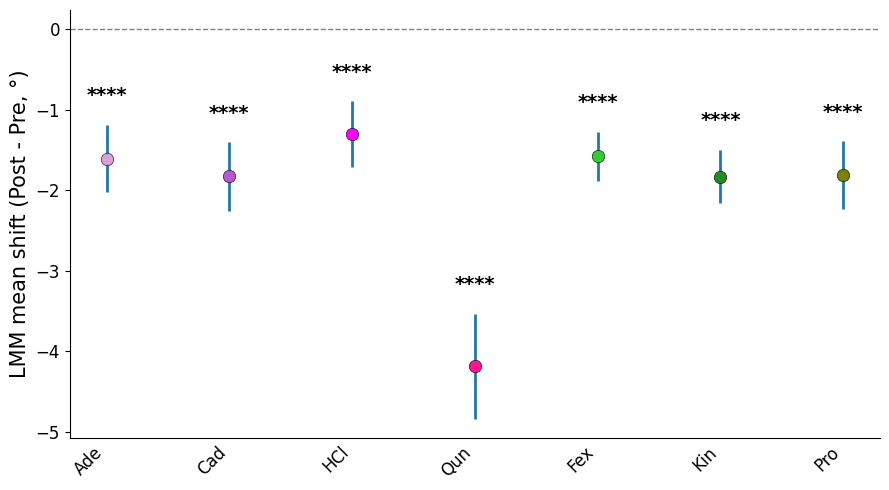

In [11]:
fig, axes = plot_paired_fish_by_stimulus(
    fish_plot_df=fish_plot_df_stimulus,
    results_df=lmm_results_df,
    group_col="stimulus_label",
    group_order=stimulus_order,
    group_title_map=stimulus_labels,
    group_color_map=stimulus_colors,
    ylabel="Posture Angle (°)",
    figsize=(12, 4),
)

plt.show()

display(effects_df)

plot_lmm_mean_shift_ci(
    effects_df=effects_df,
    stimulus_order=stimulus_order,
    stimulus_colors=stimulus_colors,
    ylabel="LMM mean shift (Post - Pre, °)"
)

# fig.savefig(f"/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures/7dpf_posture_mixed_effect_model_high_concs.svg", format="svg", dpi=300, bbox_inches="tight")


In [12]:


per_fish_summary_df.to_csv("Posture_traces_concs_mixed_model_per_stimulus.csv", index=False)

## Compare concentration levels 

In [38]:
# ============================================================
# Low vs high concentration comparison: POST-STIMULUS ONLY
# ============================================================

concentration_pairs = {
    "Cad": {
        "low": "cad_25um",
        "high": "cad_2.5mm",
    },
    "Qun": {
        "low": "qui_25um",
        "high": "qui_2.5mm",
    },
    "Pro": {
        "low": "pro_25um",
        "high": "pro_2.5mm",
    },
    "Fex": {
        "low": "fex3",
        "high": "fex1",
    },
}

stimulus_family_order = ["Cad", "Qun", "Pro", "Fex"]

conc_stims = [
    stim
    for pair in concentration_pairs.values()
    for stim in [pair["low"], pair["high"]]
]

conc_df = bhv[
    bhv["stimulus"].isin(conc_stims)
].copy()

conc_df["posture"] = conc_df.apply(
    lambda x: get_posture_trace(
        x["angles"],
        x["bout_indx"],
        extension_frames=20
    ),
    axis=1
)

conc_df["posture"] = conc_df["posture"].apply(subtract_baseline)

conc_trial_summary_df, _ = compute_trial_and_lmm_posture_tables(
    conc_df,
    posture_col="posture",
    stimulus_col="stimulus",
    fish_id_col="fish_id",
    frame_rate=frame_rate,
    stimulus_onset_s=stimulus_onset_time,
    pre_window_s=20,
    post_window_s=20,
    use_abs=True,
    low=0,
    high=np.pi
)

In [39]:
conc_df.groupby("stimulus").size()

stimulus
cad_2.5mm    60
cad_25um     60
fex1         60
fex3         60
pro_2.5mm    60
pro_25um     60
qui_2.5mm    60
qui_25um     60
dtype: int64

In [40]:
# Make a dataframe with ONLY post-stimulus tail angle

conc_post_df = conc_trial_summary_df[
    [
        "fish_id_full",
        "fish_base",
        "fish_id_clean",
        "session",
        "stimulus",
        "trial_id",
        "post_amplitude_deg"
    ]
].copy()

conc_post_df = conc_post_df.rename(
    columns={"post_amplitude_deg": "amplitude_deg"}
)


def assign_concentration_group(stim):
    for stim_family, pair in concentration_pairs.items():
        if stim == pair["low"]:
            return stim_family, "Low"
        if stim == pair["high"]:
            return stim_family, "High"
    return np.nan, np.nan


conc_post_df[["stimulus_family", "concentration"]] = conc_post_df["stimulus"].apply(
    lambda x: pd.Series(assign_concentration_group(x))
)

conc_post_df = conc_post_df.dropna(
    subset=["stimulus_family", "concentration", "amplitude_deg"]
).copy()

conc_post_df["concentration"] = pd.Categorical(
    conc_post_df["concentration"],
    categories=["Low", "High"],
    ordered=True
)

display(conc_post_df.head())

,fish_id_full,fish_base,fish_id_clean,session,stimulus,trial_id,amplitude_deg,stimulus_family,concentration
0,230713_fb,230713,230713,fb,cad_2.5mm,1,1.209475,Cad,High
1,230713_fb,230713,230713,fb,cad_2.5mm,2,1.859304,Cad,High
2,230713_fb,230713,230713,fb,cad_2.5mm,3,5.543505,Cad,High
3,230713_fb,230713,230713,fb,cad_25um,1,0.332886,Cad,Low
4,230713_fb,230713,230713,fb,cad_25um,2,0.431651,Cad,Low


In [41]:
# ============================================================
# Run LMM separately for each stimulus
# Model: post-stimulus tail angle ~ concentration
# Test: High post-stim vs Low post-stim
# ============================================================

def run_low_high_poststim_lmms(df):
    results = []
    fitted_models = {}

    for stim_family in stimulus_family_order:
        g = df[df["stimulus_family"] == stim_family].copy()

        if g.empty:
            continue

        use_session = (
            "session" in g.columns and
            g["session"].notna().any() and
            g["session"].nunique() > 1
        )

        try:
            if use_session:
                model = smf.mixedlm(
                    "amplitude_deg ~ concentration",
                    g,
                    groups=g["fish_id_clean"],
                    vc_formula={"session": "0 + C(session)"}
                )
            else:
                model = smf.mixedlm(
                    "amplitude_deg ~ concentration",
                    g,
                    groups=g["fish_id_clean"]
                )

            fit = model.fit()
            fitted_models[stim_family] = fit

            effect_name = "concentration[T.High]"
            ci = fit.conf_int()
            p_value = fit.pvalues.get(effect_name, np.nan)

            results.append({
                "stimulus_family": stim_family,
                "estimate_high_vs_low": fit.params.get(effect_name, np.nan),
                "ci_low": ci.loc[effect_name, 0] if effect_name in ci.index else np.nan,
                "ci_high": ci.loc[effect_name, 1] if effect_name in ci.index else np.nan,
                "p_value": p_value,
                "significance": p_to_symbol(p_value),
                "n_fish": g["fish_id_clean"].nunique(),
                "n_sessions": g["session"].nunique(),
                "n_trials": len(g),
            })

        except Exception as exc:
            results.append({
                "stimulus_family": stim_family,
                "estimate_high_vs_low": np.nan,
                "ci_low": np.nan,
                "ci_high": np.nan,
                "p_value": np.nan,
                "significance": "NA",
                "n_fish": g["fish_id_clean"].nunique(),
                "n_sessions": g["session"].nunique(),
                "n_trials": len(g),
                "model_error": str(exc),
            })

    return pd.DataFrame(results), fitted_models


conc_results_df, conc_fitted_models = run_low_high_poststim_lmms(conc_post_df)

display(conc_results_df)

,stimulus_family,estimate_high_vs_low,ci_low,ci_high,p_value,significance,n_fish,n_sessions,n_trials
0,Cad,1.215493,0.765507,1.665480,1.195312e-07,****,10,2,120
1,Qun,3.606480,2.965459,4.247500,2.829691e-28,****,10,2,120
2,Pro,1.296470,0.897728,1.695211,1.858073e-10,****,10,2,120
3,Fex,1.094749,0.758241,1.431256,1.814285e-10,****,10,2,120


In [42]:
# ============================================================
# Fish-level summary for plotting
# Each fish contributes one Low and one High post-stimulus value
# ============================================================

conc_fish_plot_df = (
    conc_post_df
    .groupby(
        ["fish_id_clean", "stimulus_family", "concentration"],
        observed=False
    )["amplitude_deg"]
    .mean()
    .reset_index()
)

display(conc_fish_plot_df.head())

,fish_id_clean,stimulus_family,concentration,amplitude_deg
0,230713,Cad,Low,0.488096
1,230713,Cad,High,2.197290
2,230713,Fex,Low,0.384670
3,230713,Fex,High,2.272875
4,230713,Pro,Low,0.590679


In [78]:
# ============================================================
# Plot each stimulus separately: Low post-stim vs High post-stim
# ============================================================

def plot_single_stimulus_low_high_poststim(
    fish_plot_df,
    results_df,
    stimulus_family,
    stimulus_colors,
    ylabel="Post-stimulus posture angle (°)",
    figsize=(3, 4),
    save=False,
    save_dir="/Users/bethanjenkins/Documents/valence_paper_code/FiNA/figures"
):
    g = fish_plot_df[
        fish_plot_df["stimulus_family"] == stimulus_family
    ].copy()

    paired = g.pivot_table(
        index="fish_id_clean",
        columns="concentration",
        values="amplitude_deg",
        aggfunc="mean"
    )

    paired = paired.dropna(subset=["Low", "High"])

    fig, ax = plt.subplots(figsize=figsize)

    if paired.empty:
        ax.set_title(stimulus_family, fontsize=18)
        ax.text(
            0.5, 0.5,
            "No paired Low/High data",
            ha="center",
            va="center",
            transform=ax.transAxes
        )
        return fig, ax

    low_color = stimulus_colors.get(
        f"{stimulus_family} Low",
        "lightgray"
    )

    high_color = stimulus_colors.get(
        stimulus_family,
        "gray"
    )

    for _, row in paired.iterrows():
        ax.plot(
            [0, 1],
            [row["Low"], row["High"]],
            color="0.7",
            linewidth=1.2,
            alpha=0.8,
            zorder=1
        )

    ax.scatter(
        np.zeros(len(paired)),
        paired["Low"],
        color=low_color,
        edgecolors="black",
        linewidths=0.4,
        s=40,
        zorder=2
    )

    ax.scatter(
        np.ones(len(paired)),
        paired["High"],
        color=high_color,
        edgecolors="black",
        linewidths=0.4,
        s=40,
        zorder=2
    )

    ax.hlines(
        paired["Low"].mean(),
        -0.12,
        0.12,
        color=low_color,
        linewidth=3,
        zorder=3
    )

    ax.hlines(
        paired["High"].mean(),
        0.88,
        1.12,
        color=high_color,
        linewidth=3,
        zorder=3
    )

    p_row = results_df[
        results_df["stimulus_family"] == stimulus_family
    ]

    if not p_row.empty:
        p = p_row.iloc[0]["p_value"]
        sig = p_to_symbol(p)

        y_min = np.nanmin(paired[["Low", "High"]].to_numpy())
        y_max = np.nanmax(paired[["Low", "High"]].to_numpy())
        y_range = y_max - y_min

        if y_range == 0 or not np.isfinite(y_range):
            y_range = 1

        y_sig = y_max + 0.12 * y_range

        ax.plot(
            [0, 0, 1, 1],
            [
                y_sig - 0.03 * y_range,
                y_sig,
                y_sig,
                y_sig - 0.03 * y_range
            ],
            color="black",
            linewidth=1.2
        )

        ax.text(
            0.5,
            y_sig + 0.03 * y_range,
            sig,
            ha="center",
            va="bottom",
            fontsize=14,
            fontweight="bold"
        )

        ax.set_ylim(
            y_min - 0.1 * y_range,
            y_sig + 0.2 * y_range
        )

    ax.set_xticks([0, 1])
    ax.set_xticklabels(["Low", "High"], fontsize=22, rotation=45)

    ax.set_ylabel(ylabel, fontsize=22)
    ax.set_title(stimulus_family, fontsize=18)

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.tick_params(
        axis="both",
        width=1.5,
        length=4,
        direction="out",
        labelsize=22
    )

    fig.subplots_adjust(left=0.30,
                        right=0.95,
                        bottom=0.20,
                        top=0.90)

    if save:
        fig.savefig(
            f"{save_dir}/{stimulus_family}_low_post_vs_high_post_posture_angle.svg",
            format="svg",
            dpi=300,
            bbox_inches="tight"
        )

    return fig, ax

/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_5864/802045409.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  paired = g.pivot_table(


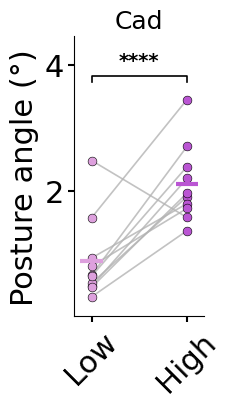

/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_5864/802045409.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  paired = g.pivot_table(


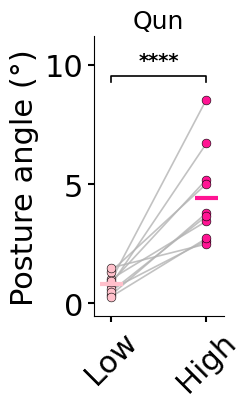

/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_5864/802045409.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  paired = g.pivot_table(


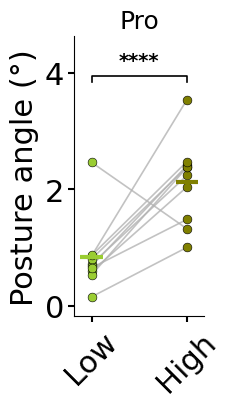

/var/folders/jq/73zm0hgn5pv677grmxk938cm0000gn/T/ipykernel_5864/802045409.py:19: FutureWarning: The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior
  paired = g.pivot_table(


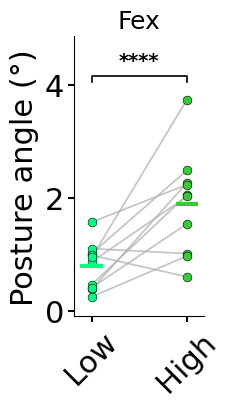

In [79]:
# Generate one separate plot per stimulus

for stim in stimulus_family_order:
    fig, ax = plot_single_stimulus_low_high_poststim(
        fish_plot_df=conc_fish_plot_df,
        results_df=conc_results_df,
        stimulus_family=stim,
        stimulus_colors=stimulus_colors,
        ylabel="Posture angle (°)",
        figsize=(2, 4),
        save=True
    )

    plt.show()